# Bracket Simulations
This notebook tests machine learning methods on their ability to predict entire brackets starting with only first round matchups rather than all individual games. 

### Methods
We simulate brackets by recursively walking a tree with the first round matchups at the leaves and the championship game at the root. We start by asking the championship game to resolve its winner, which recursively calls for the winner of each previous game until it reaches a real matchup. 

To simulate each season, we use leave-one-season-out (LOSO) cross validation and aggregate the results.

The method to predict each winner depends on the method being tested, each of which is given a `predict_win_prob(team_a, team_b, ...)`. For binary classification models, we run the model to predict win probabilities for each matchup and return that probability. For chalk simulations, we simply return a win probability of $1$ for the higher seed. For random simulations we return exactly $p=0.5$ regardless of the input teams. For the hybrid upset model, predict the probability of an upset and if the upset probability exceeds the threshold hyperparameter we return a win probability of $1$ for the lower seed, otherwise we default to the higher seed. To resolve a winner we sample uniformly against the predicted win probability.

Since all resolutions are probabilistic, we stochastically simulate 1000 brackets per model per season.

### Models
We evaluate the following models trained to predict winners:
1. Logistic Regression
2. Random Forest (n=100 estimators)
3. Support Vector Machine (SVM with Platt Scaling)
4. Single hidden layer MLP with BCE

As well as the following alternative approaches
1. Random Prediction
2. Chalk Predictions (always choose the higher seed)
3. Hybrid Upset (predict upset prob, compare to threshold)

### Evaluation
Our primary evaluation method is mean score per season using ESPN bracket scoring. We specifically compare mean per season score between all models and win season rate against random predictions based on mean simulation score. We use paired t-tests and Wilcoxon signed rank tests pairing seasons and averaging the mean difference to compare models. 

We also include visualizations for full simulated brackets relative to the true outcomes. Visualizations include single bracket summaries, probabilistic summaries for probabilistic models, and upset vs chalk comparisons for the upset model.

## Summary
 

### Import libraries

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

from src.simulation.bracket import (
    load_slots,
    build_bracket_tree, 
    simulate_bracket, 
    resolve_actual_winners, 
    nn_predict_fn,
    simulate_bracket_once, 
    hybrid_predict_fn, 
    chalk_predict_fn
)
from src.simulation.visualization import (
    plot_score_distributions,
    plot_score_trend, 
    plot_win_rate_vs_chalk,
    plot_score_heatmap, 
    plot_upset_calls,
    plot_bracket, 
    plot_slot_win_probabilities,
    build_seed_dict
)
from src.simulation.loso import load_loso_results, pairwise_comparison_table, summarize_loso_results, plot_pvalue_heatmap
from src.data.ingest import load_raw_data
from src.utils.config import load_config

In [2]:
config = load_config('configs/baseline.yaml')

raw = load_raw_data(config['data']['raw_dir'])
tourney_results = raw['tourney_results']
seeds = raw['seeds']
seeds_df = seeds

slots_df = load_slots(config['data']['raw_dir'])

experiment_name = config['data']['experiment_name']
team_stats = pd.read_csv(f'{config["data"]["processed_dir"]}/team_stats_{experiment_name}.csv')

splits_dir = f'{config["data"]["splits_dir"]}/{experiment_name}'
norm_stats = json.load(open(f'{splits_dir}/norm_stats.json'))

# real team names for the plots
teams_df = pd.read_csv(f'{config["data"]["raw_dir"]}/MTeams.csv')
team_id_to_name = dict(zip(teams_df['TeamID'], teams_df['TeamName']))

## Simulation Summaries
Plot statistical summaries for all simulations, per season mean score line plots, win rate vs chalk predictions, and a heatmap summary of all seasons average score for all models

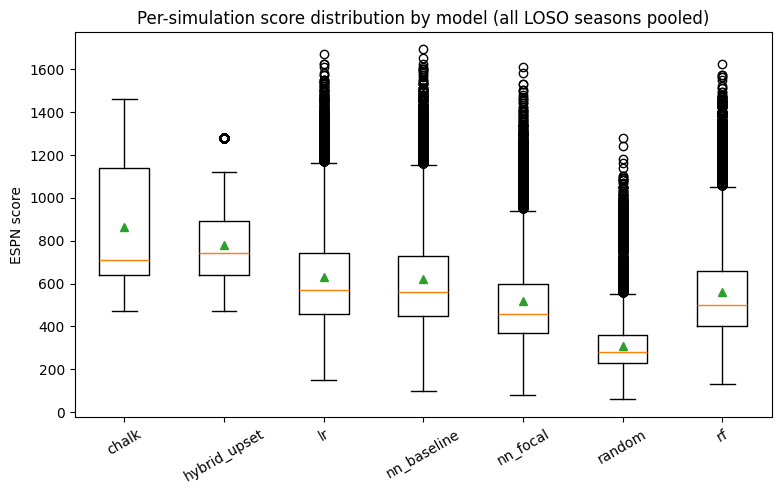

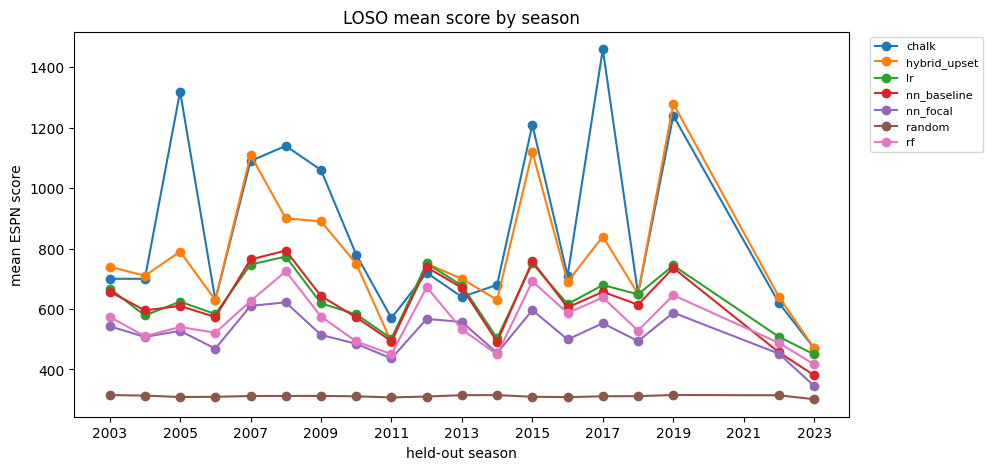

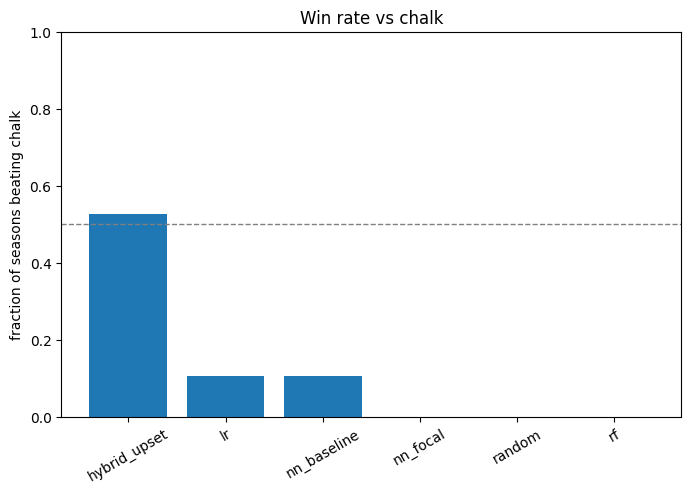

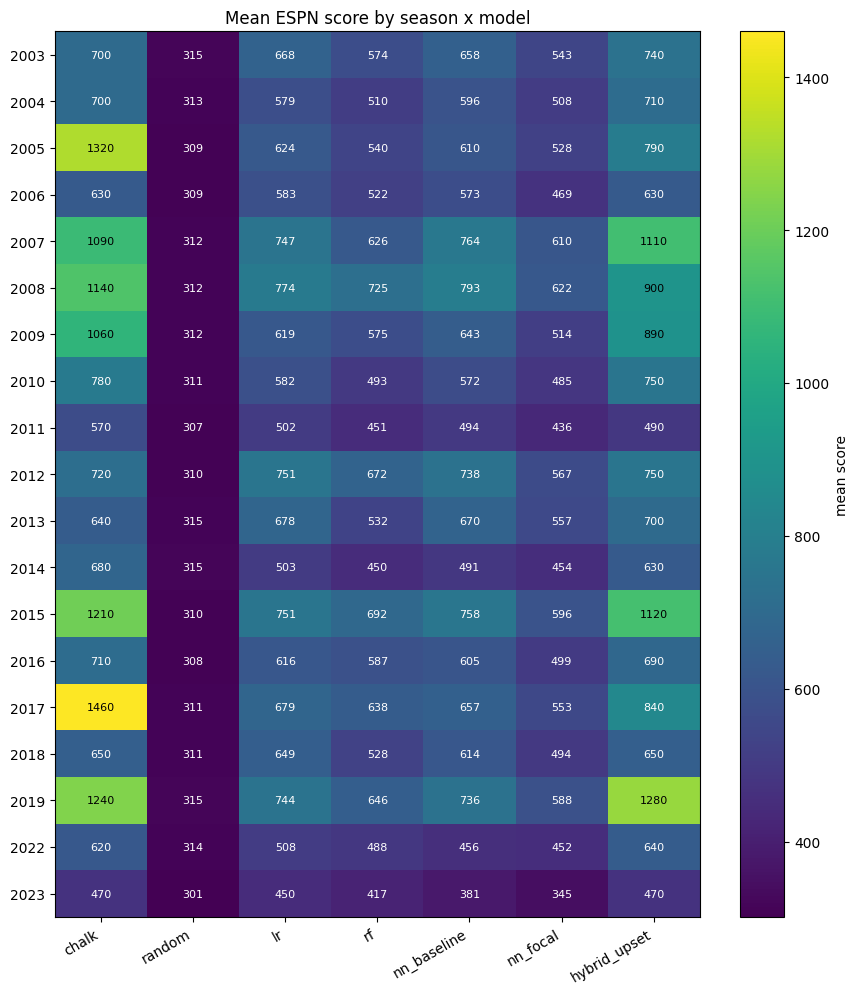

In [3]:
results_df = load_loso_results('data/processed/loso_results.csv')

plot_score_distributions(results_df)
plot_score_trend(results_df)
plot_win_rate_vs_chalk(results_df)
plot_score_heatmap(results_df, models=['chalk', 'random', 'lr', 'rf', 'nn_baseline', 'nn_focal', 'hybrid_upset'])
plt.show()

In [4]:
# statistically compare models on their full LOSO performance, paired by season
summary = summarize_loso_results(results_df)
display(summary)

,avg_mean_score,season_to_season_std,n_seasons,win_rate_vs_chalk
model,,,,
chalk,862.631579,296.363930,19,1.000000
hybrid_upset,777.894737,209.379479,19,0.526316
lr,631.951579,97.284060,19,0.105263
nn_baseline,621.559474,111.802876,19,0.105263
rf,561.292105,87.148757,19,0.000000
nn_focal,516.885263,69.029365,19,0.000000
random,311.226316,3.423786,19,0.000000


As expected, the chalk predictions score higher across almost all seasons than the traditional win predictions models, with an average over 200 points higher than the logistic regression model. However, the hybrid upset model provides the most convincing competition to chalk predictions, scoring as well as or better than chalk in 53% of seasons, indicating that the upset prediction model is more effective on full bracket simulation than any win prediction model and is potentially more effective than simply picking the higher seed. While the average mean score for chalk is higher than for the hybrid model, the hybrid model sees lower variance, potentially providing more consistent prediction outcomes since it relies on the high information seed for most predictions but has the ability to detect potential upsets that break brackets.

## Statistical Analysis
We compare performance between two models by pairing season scores, taking the difference, and then computing the mean of that difference to run a paired t-test and a Wilcoxon signed rank test. We apply Holm-Bonferroni correction to all p-values across all tests to account for false positive rates in repeated comparisons. 

First compare all models to chalk predictions

In [5]:
vs_chalk = pairwise_comparison_table(results_df, reference='chalk')
display(vs_chalk)

,model_a,model_b,n_seasons,mean_diff,t_stat,t_pvalue,t_pvalue_holm,wilcoxon_stat,wilcoxon_pvalue,wilcoxon_pvalue_holm
0,chalk,hybrid_upset,19,84.736842,1.955353,6.624828e-02,0.066248,37.5,0.114405,0.114405
1,chalk,lr,19,230.680000,4.063212,7.295695e-04,0.001459,8.0,0.000095,0.000191
2,chalk,nn_baseline,19,241.072105,4.345944,3.893688e-04,0.001168,3.0,0.000019,0.000057
3,chalk,nn_focal,19,345.746316,5.926488,1.310567e-05,0.000066,0.0,0.000004,0.000023
4,chalk,random,19,551.405263,8.126028,1.960224e-07,0.000001,0.0,0.000004,0.000023
5,chalk,rf,19,301.339474,5.362214,4.268030e-05,0.000171,0.0,0.000004,0.000023


Now compare all models against each other

In [6]:
# your own models against each other (drop chalk/random -- not a comparison you care about here)
models = [m for m in results_df['model'].unique() if m not in ('chalk', 'random')]
pairwise_comparison_table(results_df, models=models)

,model_a,model_b,n_seasons,mean_diff,t_stat,t_pvalue,t_pvalue_holm,wilcoxon_stat,wilcoxon_pvalue,wilcoxon_pvalue_holm
0,lr,rf,19,70.659474,9.015247,4.294643e-08,3.435714e-07,0.0,0.000004,0.000038
1,lr,nn_baseline,19,10.392105,1.944633,6.761419e-02,6.761419e-02,56.0,0.123188,0.123188
2,lr,nn_focal,19,115.066316,13.512663,7.297971e-11,7.297971e-10,0.0,0.000004,0.000038
3,lr,hybrid_upset,19,-145.943158,-4.345789,3.895020e-04,7.790040e-04,4.0,0.000027,0.000107
4,rf,nn_baseline,19,-60.267368,-5.779951,1.774148e-05,8.870738e-05,7.0,0.000072,0.000217
5,rf,nn_focal,19,44.406842,4.923703,1.095410e-04,4.381641e-04,9.0,0.000126,0.000252
6,rf,hybrid_upset,19,-216.602632,-6.134305,8.569867e-06,5.141920e-05,0.0,0.000004,0.000038
7,nn_baseline,nn_focal,19,104.674211,9.667052,1.500011e-08,1.350010e-07,0.0,0.000004,0.000038
8,nn_baseline,hybrid_upset,19,-156.335263,-4.915313,1.115553e-04,4.381641e-04,1.0,0.000008,0.000038
9,nn_focal,hybrid_upset,19,-261.009474,-7.166648,1.131376e-06,7.919632e-06,0.0,0.000004,0.000038


Finally compare all models with all models and generate a heatmap for visualization of the Holm corrected Wilcoxon p-values

,model_a,model_b,n_seasons,mean_diff,t_stat,t_pvalue,t_pvalue_holm,wilcoxon_stat,wilcoxon_pvalue,wilcoxon_pvalue_holm
0,chalk,hybrid_upset,19,84.736842,1.955353,6.624828e-02,1.324966e-01,37.5,0.114405,0.228809
1,chalk,lr,19,230.680000,4.063212,7.295695e-04,2.188708e-03,8.0,0.000095,0.000381
2,chalk,nn_baseline,19,241.072105,4.345944,3.893688e-04,1.946844e-03,3.0,0.000019,0.000134
3,chalk,nn_focal,19,345.746316,5.926488,1.310567e-05,1.310567e-04,0.0,0.000004,0.000080
4,chalk,random,19,551.405263,8.126028,1.960224e-07,2.548291e-06,0.0,0.000004,0.000080
5,chalk,rf,19,301.339474,5.362214,4.268030e-05,3.414424e-04,0.0,0.000004,0.000080
6,hybrid_upset,lr,19,145.943158,4.345789,3.895020e-04,1.946844e-03,4.0,0.000027,0.000160
7,hybrid_upset,nn_baseline,19,156.335263,4.915313,1.115553e-04,7.667872e-04,1.0,0.000008,0.000080
8,hybrid_upset,nn_focal,19,261.009474,7.166648,1.131376e-06,1.357651e-05,0.0,0.000004,0.000080
9,hybrid_upset,random,19,466.668421,9.776948,1.262318e-08,2.019708e-07,0.0,0.000004,0.000080


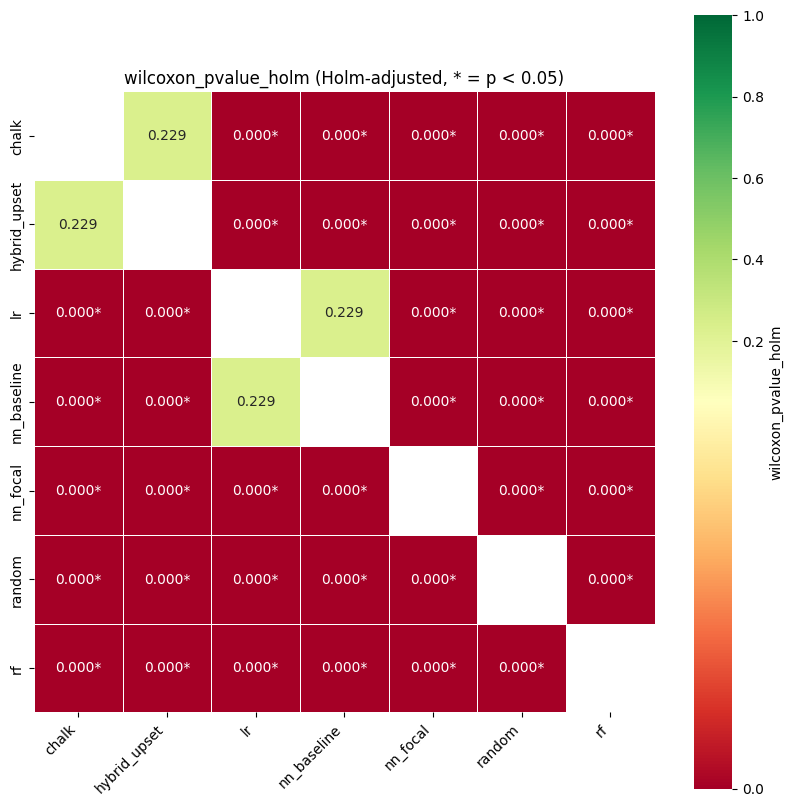

In [10]:
table = pairwise_comparison_table(results_df)
display(table)
plot_pvalue_heatmap(table, pvalue_col='wilcoxon_pvalue_holm', alpha=0.05)
plt.tight_layout()
plt.show()

Since all tests conducted are two-sided tests, we must look at the mean difference to determine the direction of each result. Comparing all models against each other, we see that there is a statistically significant difference in the average mean score for all model pairs except for the base neural network and the logistic regression both predicting winners, and the chalk and hybrid upset approach. This means there is no statistically significant evidence that the models differ in performance between chalk and hybrid, even though chalk has a higher sample mean.

## Visualization
We draw brackets for the unseen test season 2025 for both the baseline neural network predicting winners and the hybrid upset model. 

For the neural net that returns a win probability we graph both a single simulation and a probability distribution of all the games, displaying the most often picked winner and the true winner if it differs.

For the upset hybrid model, we display a bracket comparing the chalk seed winners and highlight where the upset calls differ. We also visualize a single bracket prediction of the upset model.

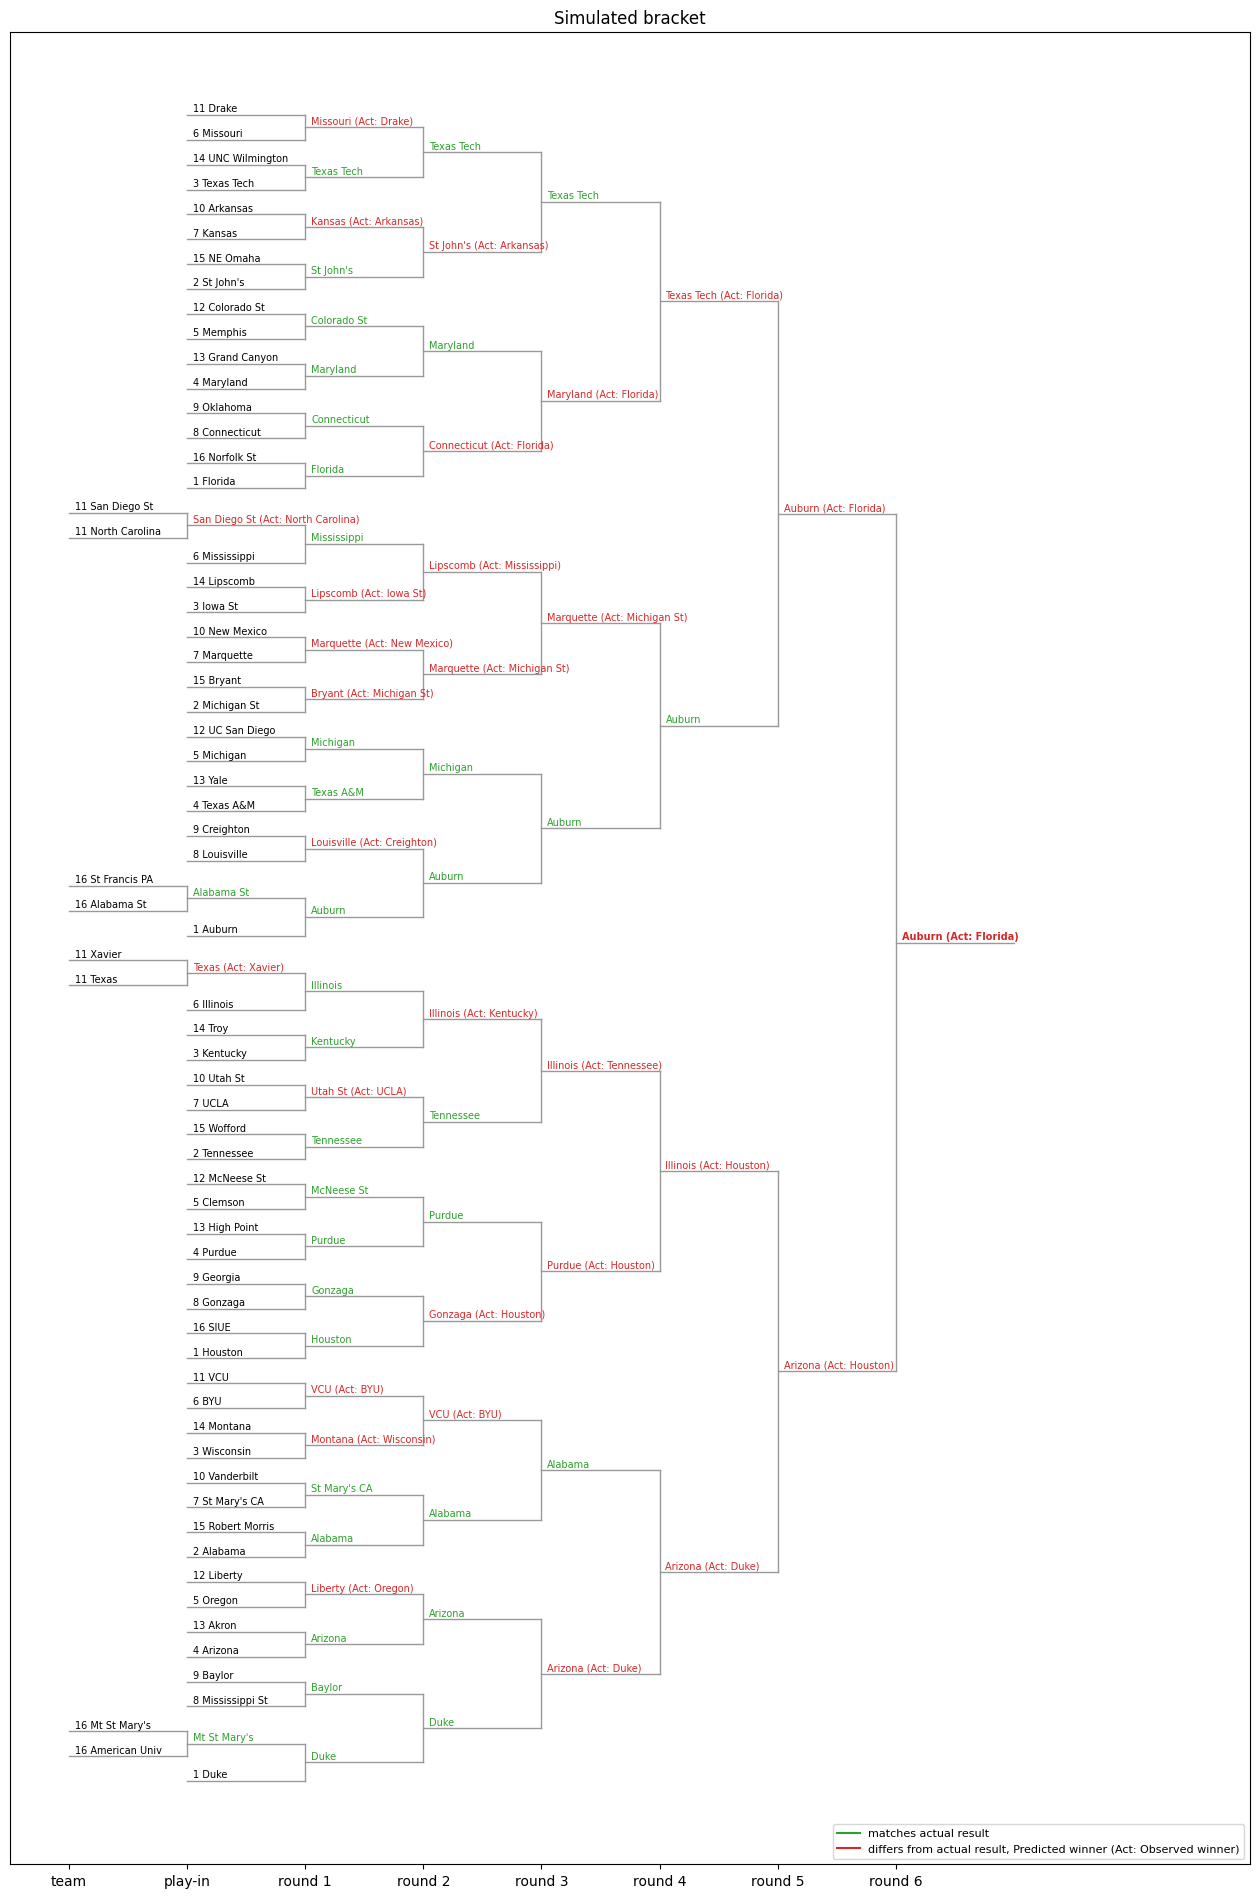

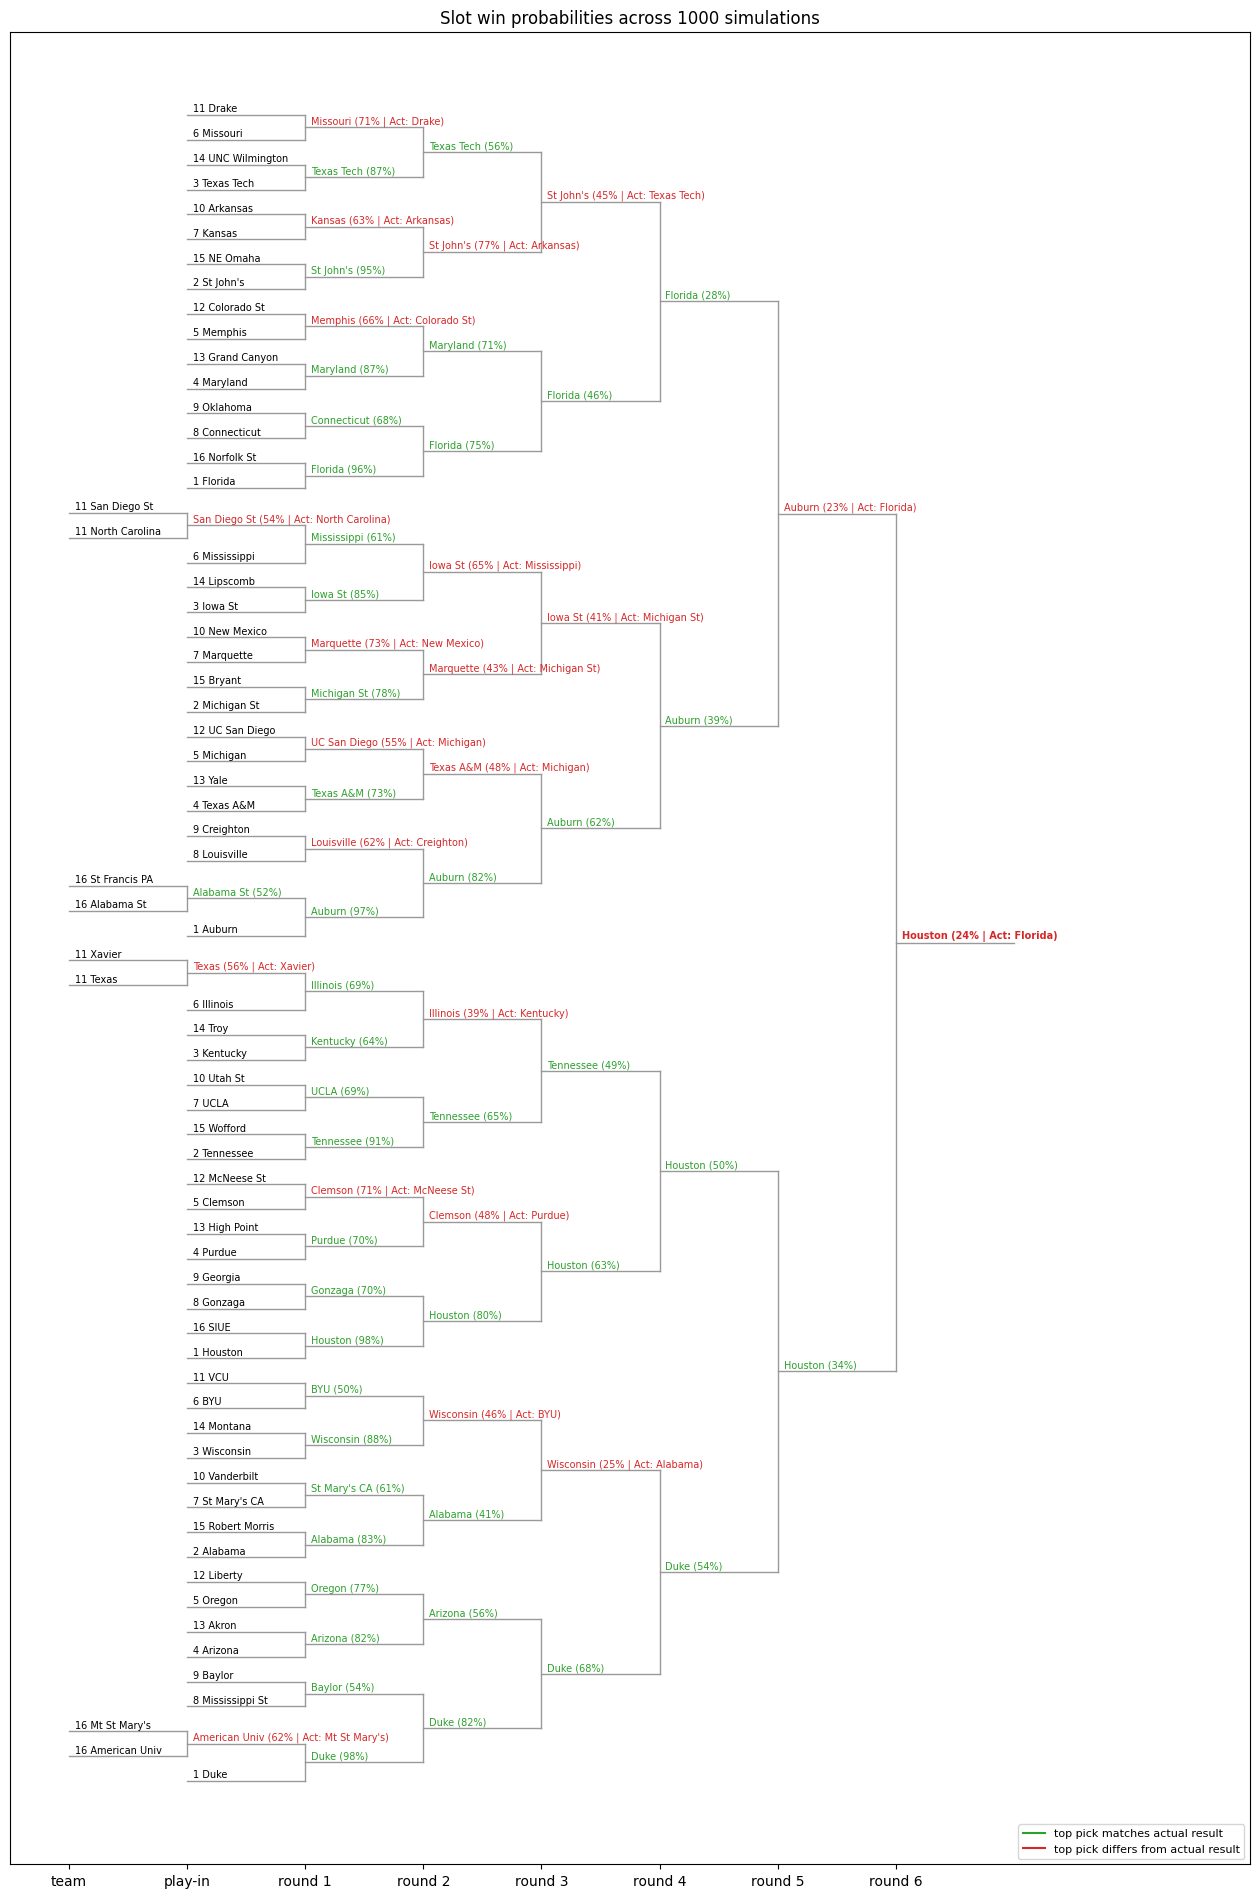

In [8]:
season = 2025

tree = build_bracket_tree(season, slots_df, seeds_df)
predict_fn = nn_predict_fn(config, team_stats, seeds, norm_stats)
sims = simulate_bracket(season, tree, predict_fn, n_sims=1000, random_seed=42, model_name='nn_baseline')
actual = resolve_actual_winners(season, tree, tourney_results)
seed_dict = build_seed_dict(season, seeds_df)

plot_bracket(tree, sims[0], actual_winners=actual, team_names=team_id_to_name, seeds=seed_dict)
plot_slot_win_probabilities(tree, sims, actual_winners=actual, team_names=team_id_to_name, seeds=seed_dict)
plt.show()

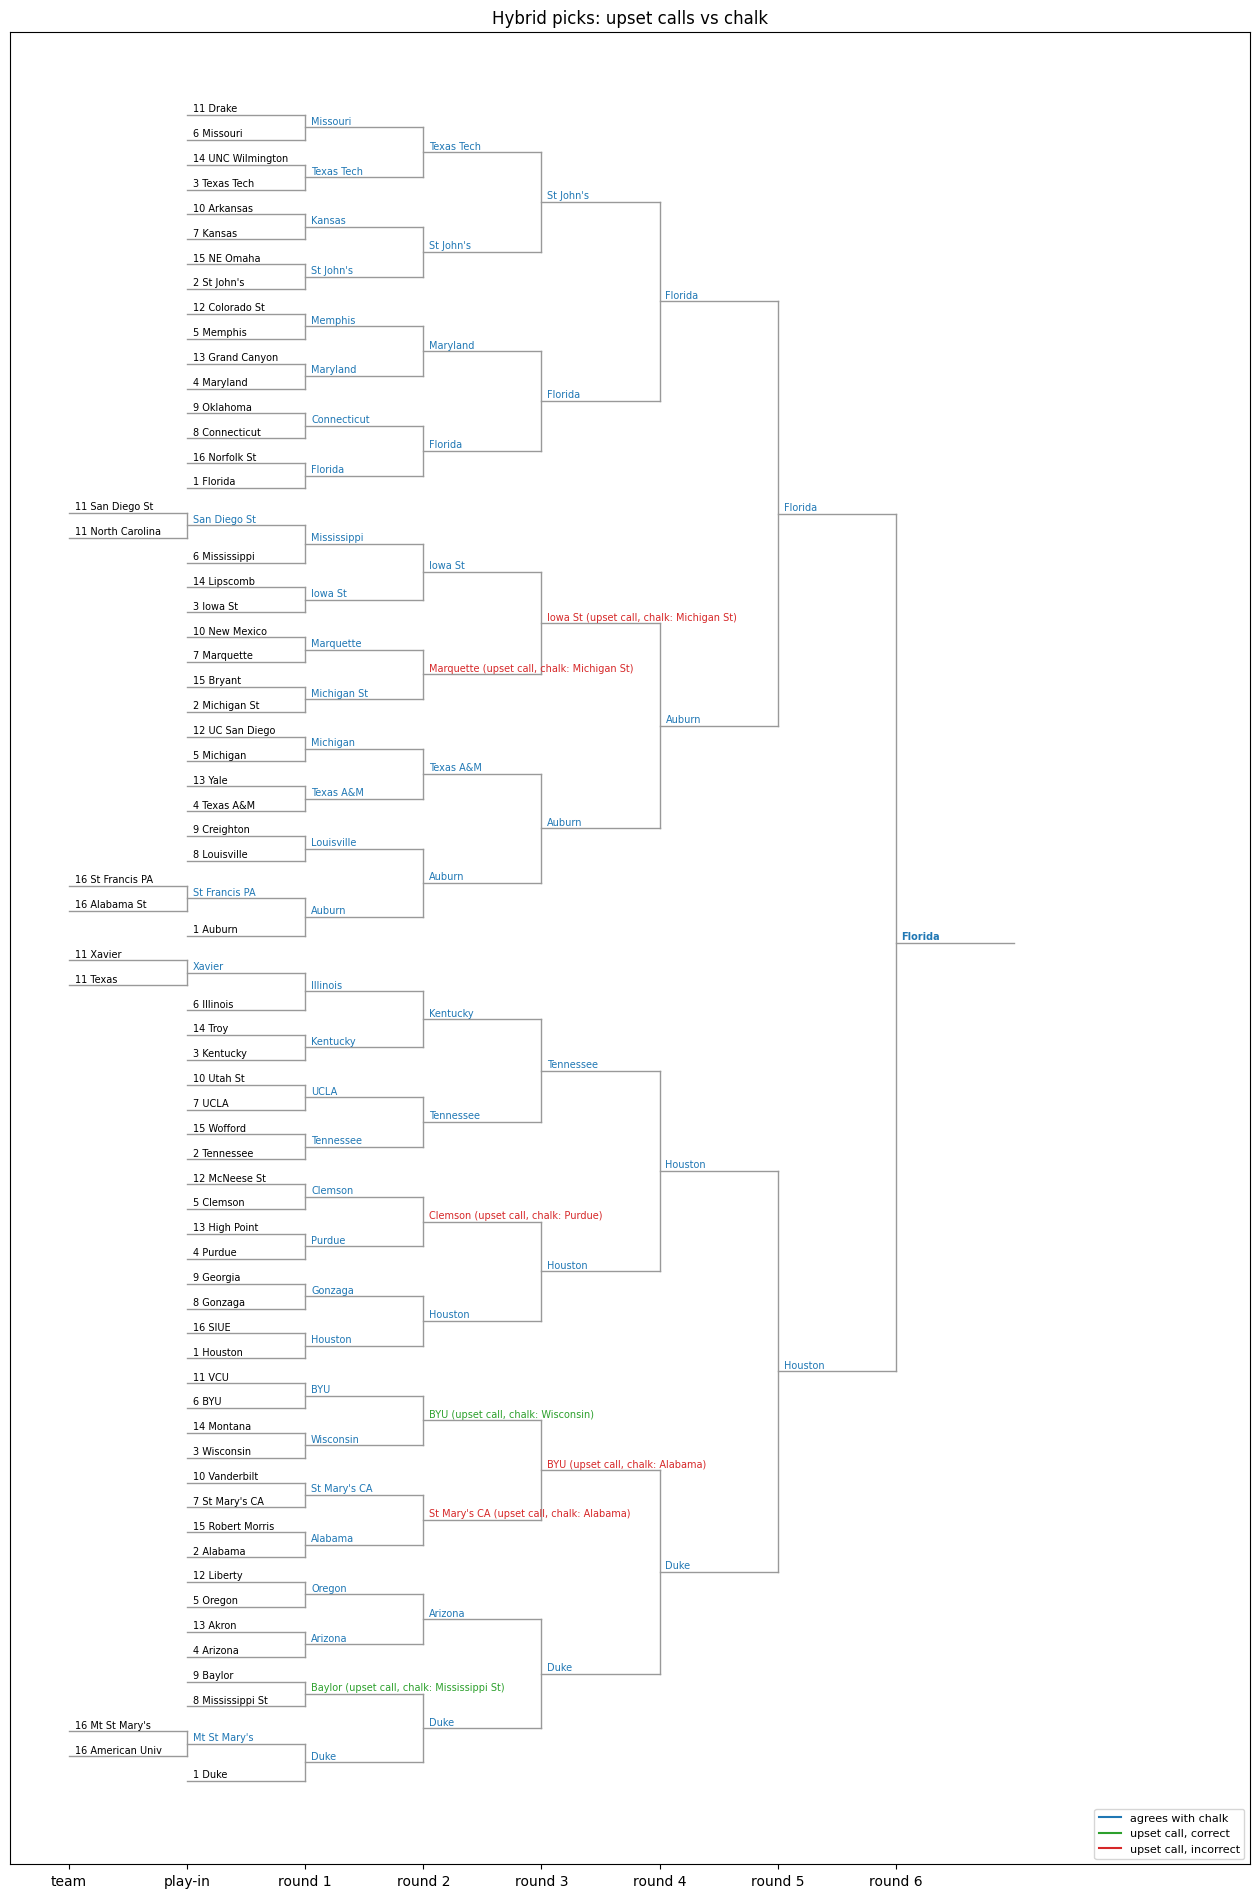

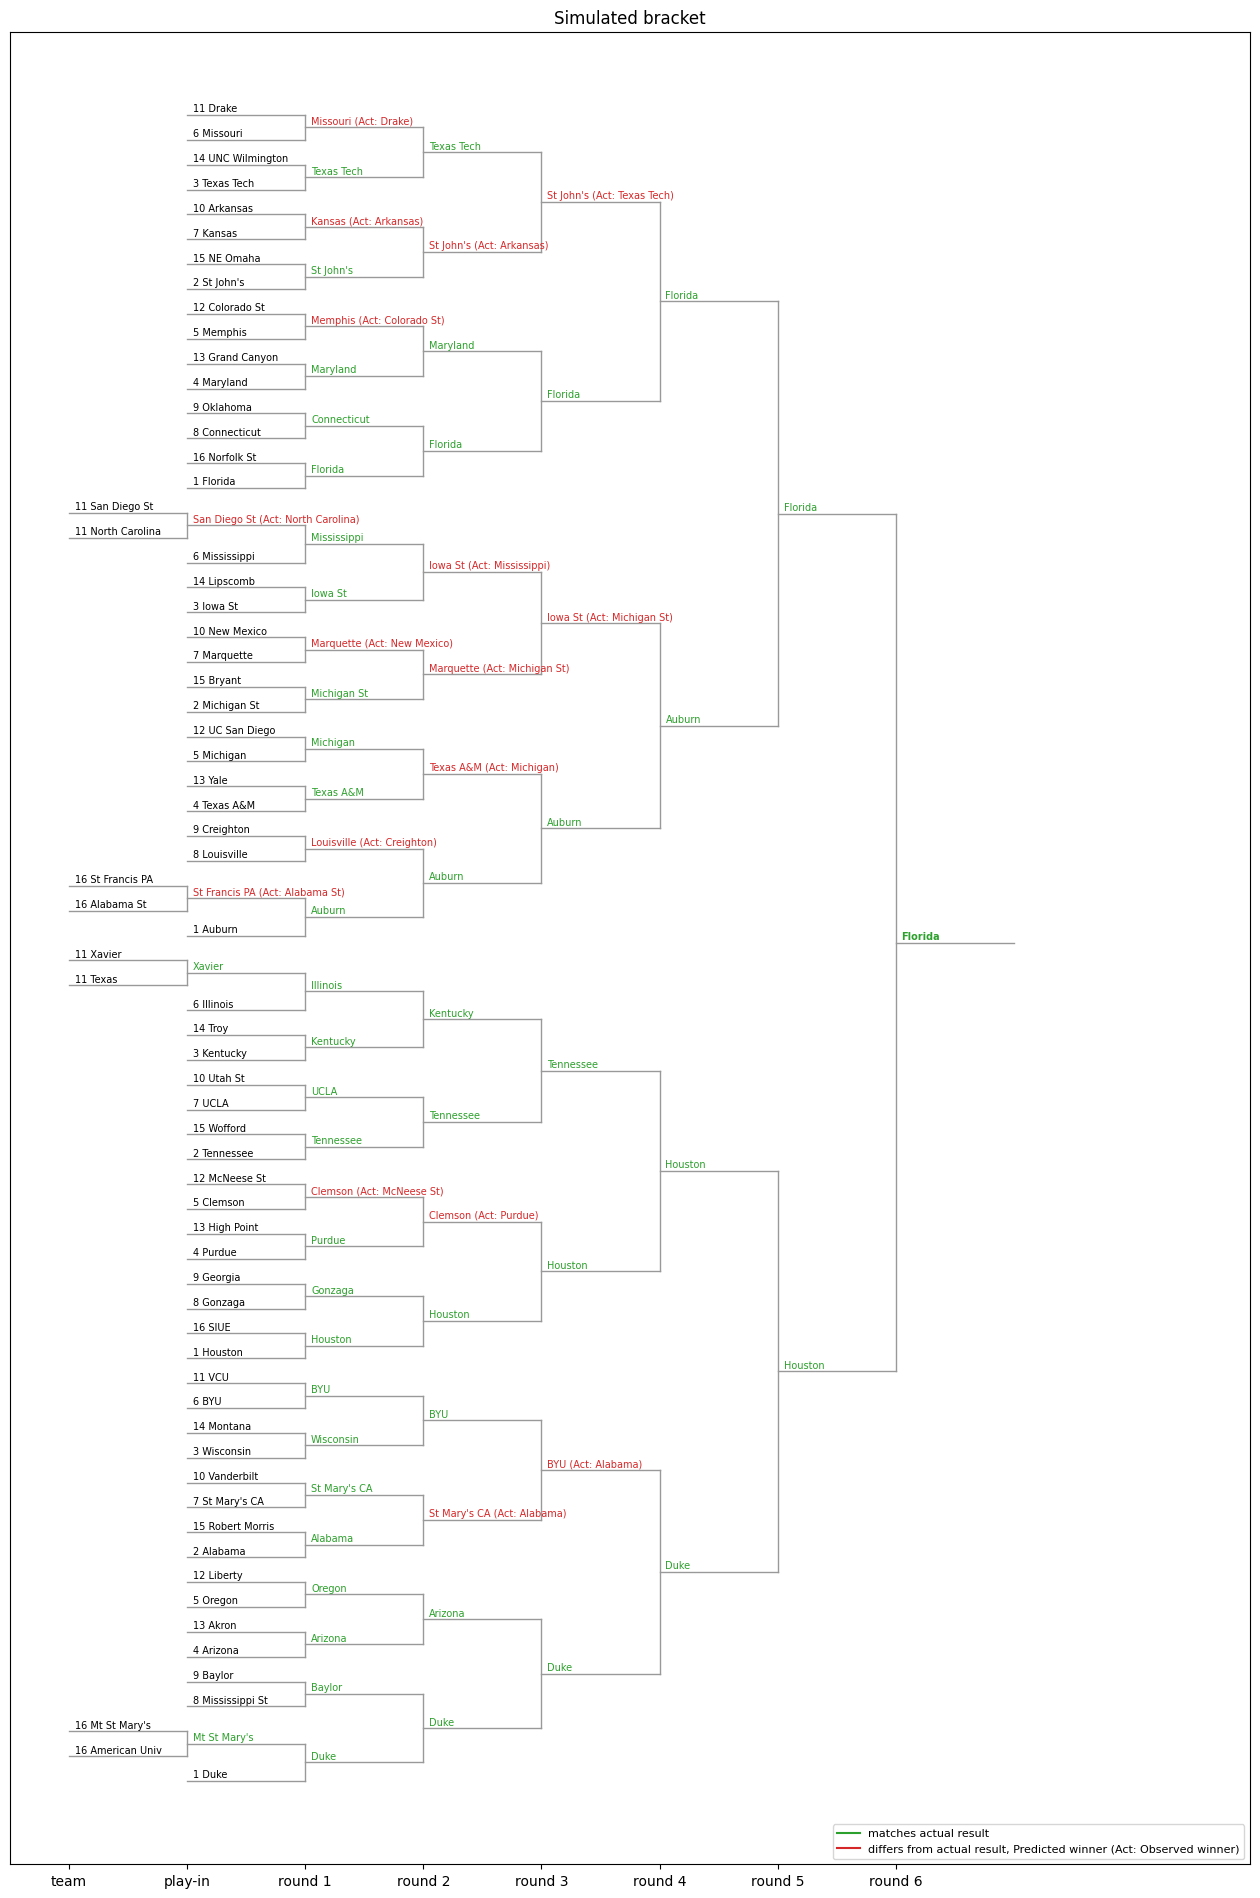

In [9]:
upset_config = load_config('configs/upset.yaml')
upset_splits_dir = f'{upset_config["data"]["splits_dir"]}/{upset_config["data"]["experiment_name"]}'
upset_norm_stats = json.load(open(f'{upset_splits_dir}/norm_stats.json'))

upset_predict_fn = nn_predict_fn(upset_config, team_stats, seeds, upset_norm_stats)
chalk_fn = chalk_predict_fn(seeds)
hybrid_fn = hybrid_predict_fn(seeds, upset_predict_fn, threshold=0.5)

season = 2025

rng = np.random.default_rng(42)
tree = build_bracket_tree(season, slots_df, seeds)
actual = resolve_actual_winners(season, tree, tourney_results)
chalk_winners = simulate_bracket_once(season, tree, chalk_fn, rng)
hybrid_winners = simulate_bracket_once(season, tree, hybrid_fn, rng)
seed_dict = build_seed_dict(season, seeds_df)

plot_upset_calls(tree, hybrid_winners, chalk_winners, actual_winners=actual, team_names=team_id_to_name, seeds=seed_dict)
plot_bracket(tree, hybrid_winners, actual, team_names=team_id_to_name, seeds=seed_dict)
plt.show()